# Bumble user behavior analysis (Python)

**Exploratory analytics case study:** ingest → cleanse → engineered features → segmented visuals → business takeaways geared for recruiter, GitHub, and LinkedIn skim.

_Educational portfolio piece — sample extract, not live product data._


## Executive Summary

Recruiter snapshot: repeatable **EDA on structured profiles**, explicit **income withheld (−1) handling**, segmentation visuals, crisp product-linked language.

### Headline findings
- **Audience ~60 % male / ~40 % female** → classic asymmetric-market competition; fairness and backlog KPIs dominate.
- **Intent concentrates on "single"** → product narrative stays dating-first versus vague social-graph positioning.
- **Income largely withheld historically** → treat tier-based views cautiously unless verified subsets back monetization tests.
- **Age shows a modest exploratory income uplift** → supports lifecycle hypotheses, not deterministic scoring.
- **Metro clusters concentrate eyeballs** → efficient local spend; beware global extrapolation.

### Preview recommendations (detailed later)
1. Balance discovery ethically and watch reply/session quality deltas.
2. Prefer low-friction trust signals over forced salary disclosures users skip.


## Project context

### Business angle  
Rich profile fields underpin **matching, safety, personalization, moderation, and acquisition ROI** — exploratory rigor on field quality pays downstream.

### Analytical charter  
Produce a repeatable narrative: sentinel cleanup, categorical harmonization from messy text, time features where useful, segmented distributions, succinct stakeholder takeaway.


---
## Imports & plotting defaults


In [1]:
# To refresh embedded PNG outputs (no Jupyter kernel): python offline_execute_notebook.py
%matplotlib inline

import warnings

warnings.filterwarnings("ignore")

from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})

FIG_SM = (7.5, 4.25)
FIG_MD = (9.5, 4.8)
FIG_LG = (11, 5.2)
FIG_XL = (11.5, 6.5)

GENDER_TICKS = {"m": "Male", "f": "Female"}


---
## Dataset loading

Canonical path (`dataset/` keeps this repo tidy for GitHub clones).


In [2]:
df = pd.read_csv("dataset/bumble_profiles.csv")

print(f"Rows: {len(df):,}  •  Columns: {df.shape[1]}")


Rows: 59,946  •  Columns: 17


In [3]:
df.head(6)


,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,-1,transportation,2012-06-28-20-30,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000,hospitality / travel,2012-06-29-21-41,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (..."
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,-1,NaN,2012-06-27-09-10,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++"
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000,student,2012-06-28-14-22,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)"
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,2012-06-27-21-26,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english
5,29,single,m,average,mostly anything,socially,graduated from college/university,white,67.0,-1,computer / hardware / software,2012-06-29-19-18,"san francisco, california",likes cats,atheism,taurus,"english (fluently), chinese (okay)"


In [4]:
df.dtypes


age              int64
status             str
gender             str
body_type          str
diet               str
drinks             str
education          str
ethnicity          str
height         float64
income           int64
job                str
last_online        str
location           str
pets               str
religion           str
sign               str
speaks             str

**Snapshot:** categorical self-descriptors plus numeric `age`, `height`, `income`, and ISO-like `last_online` strings—not yet timezone-aware.


---
## Cleaning & baseline quality


Normalize `last_online` for any time-derived features.


In [5]:
df["last_online"] = pd.to_datetime(df["last_online"], format="%Y-%m-%d-%H-%M")


Drop the handful of rows missing height—minimal loss and avoids fabricating biometric values.


In [6]:
df = df.dropna(subset=["height"]).copy()
df.shape


(59943, 17)

---
## Missingness scan


In [7]:
missingness_by_column = pd.DataFrame({
    "MissingCount": df.isnull().sum(),
    "Pct": (df.isnull().sum() / len(df)).mul(100).round(2),
}).sort_values("Pct", ascending=False)

missingness_by_column[missingness_by_column["Pct"] > 0].head(12)


,MissingCount,Pct
diet,24392,40.69
religion,20223,33.74
pets,19919,33.23
sign,11054,18.44
job,8196,13.67
education,6625,11.05
ethnicity,5679,9.47
body_type,5293,8.83
drinks,2982,4.97
speaks,50,0.08


In [8]:
cols_over_half_missing = (df.isnull().mean()).loc[lambda s: s > 0.5]
cols_over_half_missing  # Empty → no wholesale column drops at 50%+ threshold


Series([], )

### Insight

Sparse text-heavy fields dominate missingness bands; withhold judgment until sentinel rules (`income`) are applied.


Treat unknown diet / pets / religion as labeled unknowns—not dropped.


In [9]:
for col in ["diet", "pets", "religion"]:
    df[col] = df[col].fillna("Unknown")


---
## Outlier review & income sentinels

Age distribution first; withholding uses `-1`, which must not enter aggregates.


In [10]:
df["age"].describe().round(1)


count    59943.0
mean        32.3
std          9.5
min         18.0
25%         26.0
50%         30.0
75%         37.0
max        110.0

In [11]:
df["income"].describe().round(0)


count      59943.0
mean       20034.0
std        97349.0
min           -1.0
25%           -1.0
50%           -1.0
75%           -1.0
max      1000000.0

### Insight

Map `-1` to null before summaries or models so medians/means aren’t mechanically pulled down.


In [12]:
pct_income_withheld_initial = df["income"].eq(-1).mean() * 100

df.loc[df["income"].eq(-1), "income"] = np.nan

round(pct_income_withheld_initial, 1)


np.float64(80.8)

Roughly ~80% withheld income historically—premium trust features or softer proxies matter more than raw dollar fields.


---
## Feature engineering


Time parts for hourly / weekly analyses if expanded later.


In [13]:
df["online_hour"] = df["last_online"].dt.hour
df["day_of_week"] = df["last_online"].dt.day_name()

df[["last_online", "online_hour", "day_of_week"]].head(3)


,last_online,online_hour,day_of_week
0,2012-06-28 20:30:00,20,Thursday
1,2012-06-29 21:41:00,21,Friday
2,2012-06-27 09:10:00,9,Wednesday


Stratified income fill: median **within gender × age band**, then dataset median.


In [14]:
df["age_band"] = pd.cut(df["age"], bins=[18, 25, 35, 45, 55, 65, 100])

df["income"] = df["income"].fillna(df.groupby(["gender", "age_band"])["income"].transform("median"))
df["income"] = df["income"].fillna(df["income"].median())


In [15]:
df["income_tier"] = pd.qcut(
    df["income"],
    q=3,
    labels=["Low Income", "Medium Income", "High Income"],
)


In [16]:
tier_share_pct = df["income_tier"].value_counts(normalize=True).mul(100).round(1)

tier_share_pct.to_frame("% of analytic frame")


,% of analytic frame
income_tier,
Low Income,43.4
Medium Income,35.3
High Income,21.4


Roughly balanced tertiles stem from `pd.qcut` mathematics—informative tier labels for charts, **not** a discovered natural cluster.


In [17]:
df["height_cm"] = df["height"] * 2.54


Condense diet wording into manageable merchandise / filter buckets.


In [18]:
diet_simple = df["diet"].replace({
    "vegetarian": "Vegetarian", "mostly vegetarian": "Vegetarian", "strictly vegetarian": "Vegetarian",
    "vegan": "Vegan", "mostly vegan": "Vegan", "strictly vegan": "Vegan",
    "anything": "Anything", "mostly anything": "Anything", "strictly anything": "Anything",
    "halal": "Halal", "mostly halal": "Halal", "strictly halal": "Halal",
    "kosher": "Kosher", "mostly kosher": "Kosher", "strictly kosher": "Kosher",
    "other": "Mixed / other", "mostly other": "Mixed / other", "strictly other": "Mixed / other",
}).fillna("Unknown")

df["diet_bucket"] = diet_simple


Geography tokens for localization.


In [19]:
df[["city_clean", "state_clean", "location_remainder"]] = df["location"].str.split(",", expand=True)
df["city_clean"] = df["city_clean"].str.strip().str.title()
df["state_clean"] = df["state_clean"].str.strip().str.title()

df[["location", "city_clean", "state_clean"]].head(3)


,location,city_clean,state_clean
0,"south san francisco, california",South San Francisco,California
1,"oakland, california",Oakland,California
2,"san francisco, california",San Francisco,California


Zodiac token extraction for exploratory lifestyle charts.


In [20]:
df["sign_standard"] = df["sign"].str.extract(
    r"(aries|taurus|gemini|cancer|leo|virgo|libra|scorpio|sagittarius|capricorn|aquarius|pisces)",
    expand=False,
)


Binary gender encoding **only** for correlation visuals.


In [21]:
df["gender_encoded"] = df["gender"].map({"m": 0, "f": 1})


Duplicates check after transforms.


In [22]:
duplicate_profile_rows = int(df.duplicated().sum())

duplicate_profile_rows


0

---
## Analysis & visuals

Audience mix, intent, correlations, wallets, locality, physique, hobbies—tables stay lean where a chart replaces them.


### Audience mix


In [23]:
audience_share = pd.DataFrame({
    "Pct": df["gender"].map(GENDER_TICKS).value_counts(normalize=True).mul(100).round(2),
}).join(df["gender"].map(GENDER_TICKS).value_counts().rename("Count"))

audience_share


,Pct,Count
gender,,
Male,59.77,35827
Female,40.23,24116


Quant view first; stacked bars next confirm directional skew without reinventing KPIs.


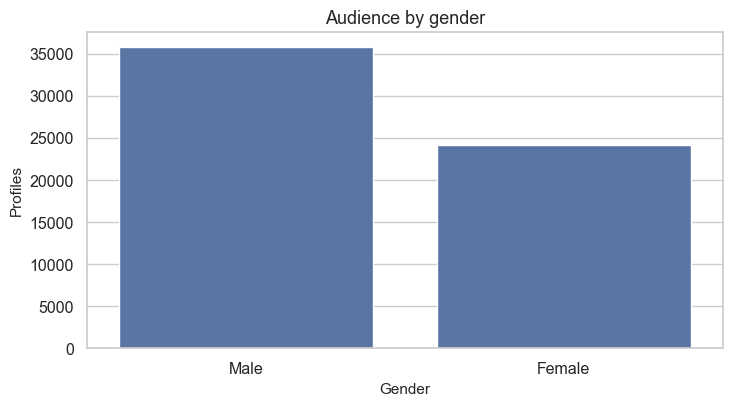

In [24]:
fig, ax = plt.subplots(figsize=FIG_SM)

sns.countplot(ax=ax, data=df, x="gender", order=["m", "f"])
ax.set_xticks([0, 1])
ax.set_xticklabels(["Male", "Female"])
ax.set_title("Audience by gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Profiles")
plt.tight_layout()
plt.show()


### Insight

Roughly six in ten profiles read male—in similar apps that usually increases competition on one side of the marketplace and lowers reply rates unless discovery is adjusted.


### Relationship status & intent


In [25]:
intent_mix = pd.DataFrame({
    "%": df["status"].value_counts(normalize=True).mul(100).round(2),
})

intent_mix


,%
status,
single,92.91
seeing someone,3.44
available,3.11
married,0.52
unknown,0.02


### Insight

“Single” dominates table space; the histogram below is mostly a proportional confirmation for exec readers.


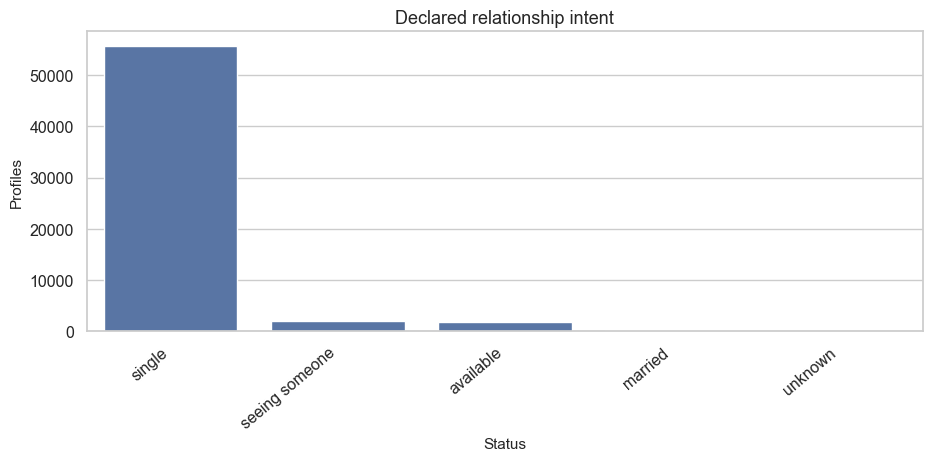

In [26]:
fig, ax = plt.subplots(figsize=FIG_MD)
order = df["status"].value_counts().index.tolist()
sns.countplot(ax=ax, data=df, x="status", order=order)
ax.set_title("Declared relationship intent")
ax.set_xlabel("Status")
ax.set_ylabel("Profiles")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


### Insight

Status skews overwhelmingly single—a strong fit for classic dating KPIs rather than ambiguous social-graph goals.


### Gender × intent shares


In [27]:
intent_pct_by_gender = pd.crosstab(df["gender"], df["status"], normalize="index").mul(100).round(1)
intent_pct_by_gender


status,available,married,seeing someone,single,unknown
gender,,,,,
f,2.7,0.6,4.2,92.5,0.0
m,3.4,0.5,3.0,93.2,0.0


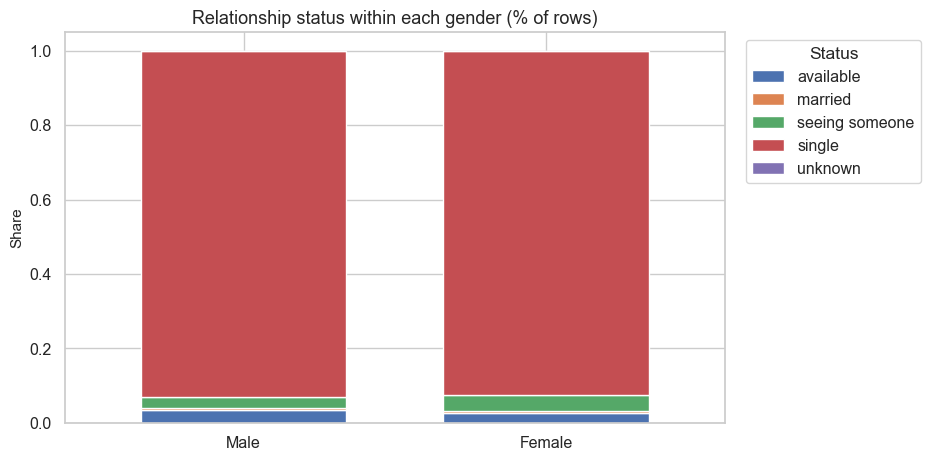

In [28]:
intent_for_plot = pd.crosstab(df["gender"], df["status"], normalize="index")
intent_for_plot.index = intent_for_plot.index.map({"m": "Male", "f": "Female"})

intent_for_plot = intent_for_plot.reindex(["Male", "Female"]).dropna(how="all")

ax = intent_for_plot.plot(kind="bar", stacked=True, figsize=FIG_MD, width=0.68)
ax.set_title("Relationship status within each gender (% of rows)")
ax.set_xlabel("")
ax.set_ylabel("Share")
plt.xticks(rotation=0)
plt.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()


### Insight

Non-single slices are slim but nonzero—matching logic and safety tooling should silently handle mixed intent.


### Demographic correlations (linear view)


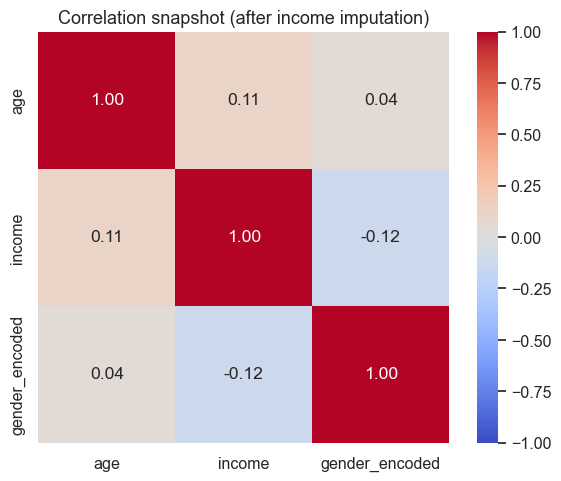

In [29]:
fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(
    df[["age", "income", "gender_encoded"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Correlation snapshot (after income imputation)")
plt.tight_layout()
plt.show()


### Interpretation · correlation heatmap

The annotated matrix captures **Pearson coefficients after income imputation**. The comparatively **strongest linear pairing is usually age versus income**: a modest positive tilt consistent with earnings rising across career stages, while **scatter variance still dominates**, so personalization and forecasting need behavioral or verified attributes—not this matrix alone. Correlations involving **gender (encoded)** stay near zero, meaning **experimentation with calibrated segments beats naïve linear demographic scoring.**


### Lifestyle — diet


In [30]:
diet_share_pct = df["diet_bucket"].value_counts(normalize=True).mul(100).round(2)
diet_share_pct


diet_bucket
Anything         46.51
Unknown          40.69
Vegetarian        8.32
Mixed / other     2.99
Vegan             1.17
Kosher            0.19
Halal             0.13

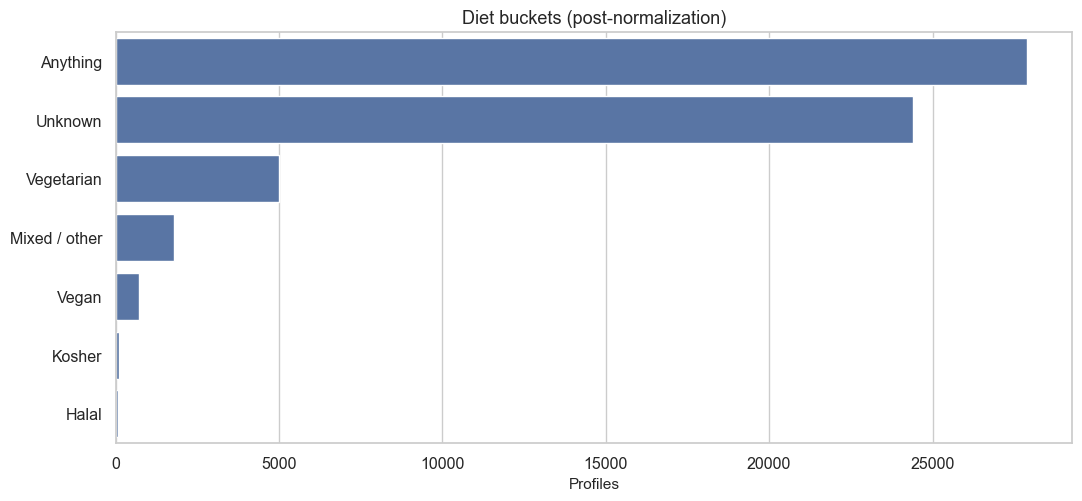

In [31]:
bucket_order = diet_share_pct.index.tolist()

fig, ax = plt.subplots(figsize=FIG_LG)
sns.countplot(ax=ax, data=df, y="diet_bucket", order=bucket_order)
ax.set_title("Diet buckets (post-normalization)")
ax.set_xlabel("Profiles")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### Insight

“Flexible eater” dominates; vegetarian-aligned clusters still warrant filter defaults and onboarding suggestions.


### Drinking × diet


In [32]:
drinks_by_diet_pct = pd.crosstab(df["diet_bucket"], df["drinks"], normalize="index").mul(100).round(1)

drinks_by_diet_pct


drinks,desperately,not at all,often,rarely,socially,very often
diet_bucket,,,,,,
Anything,0.6,4.8,9.7,8.7,75.3,0.9
Halal,5.7,30.0,7.1,12.9,35.7,8.6
Kosher,6.2,10.6,5.3,19.5,51.3,7.1
Mixed / other,1.3,11.2,6.2,17.4,62.9,0.9
Unknown,0.4,5.7,8.8,11.1,73.3,0.7
Vegan,1.8,18.1,9.0,17.4,52.7,1.0
Vegetarian,0.7,6.6,7.8,13.6,70.5,0.8


### Insight

Cross-tab nuances help campaign creative (Dry January vs brunch occasions) rather than coarse demographic cuts alone.


### Geography concentration


In [33]:
city_volume_top5 = df["city_clean"].value_counts().head(5)

state_volume_top5 = df["state_clean"].value_counts().head(5)

display(city_volume_top5.to_frame("Profiles"))

display(state_volume_top5.to_frame("Profiles"))


,Profiles
city_clean,
San Francisco,31064
Oakland,7214
Berkeley,4210
San Mateo,1331
Palo Alto,1064


,Profiles
state_clean,
California,59853
New York,17
Illinois,8
Massachusetts,5
Oregon,4


In [34]:
mean_age_top_markets = (
    df.loc[df["city_clean"].isin(city_volume_top5.index)]
      .groupby("city_clean")["age"]
      .mean()
      .sort_values()
      .round(1)
)

mean_age_top_markets


city_clean
Berkeley         31.4
San Francisco    31.6
Palo Alto        32.0
Oakland          33.2
San Mateo        33.4

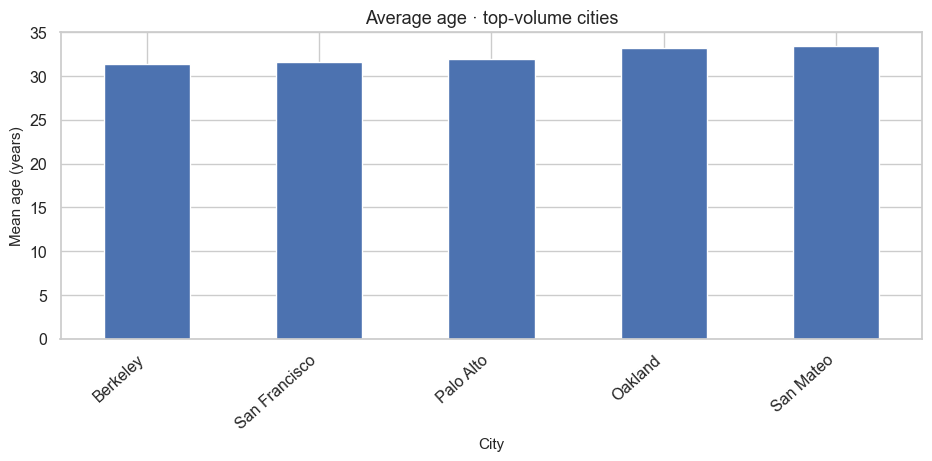

In [35]:
fig, ax = plt.subplots(figsize=FIG_MD)
mean_age_top_markets.sort_values().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Average age · top-volume cities")
ax.set_xlabel("City")
ax.set_ylabel("Mean age (years)")
plt.xticks(rotation=42, ha="right")
plt.tight_layout()
plt.show()


### Insight

Hyper-local density (Bay-heavy in this slice) concentrates acquisition spend and moderates generalized global benchmarks.


### Physique — height


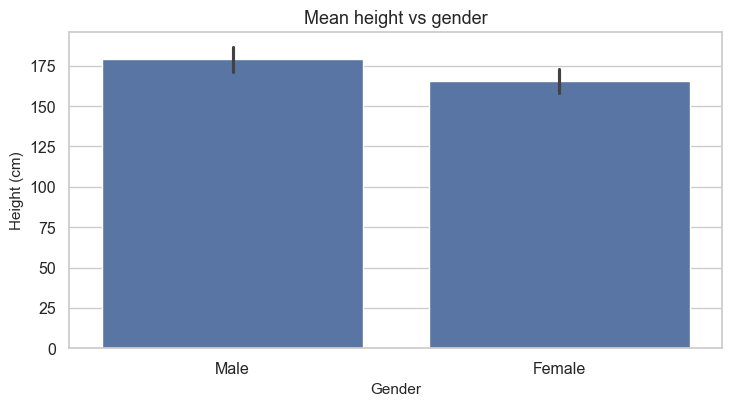

In [36]:
fig, ax = plt.subplots(figsize=FIG_SM)
sns.barplot(ax=ax, data=df, x="gender", y="height_cm", order=["m", "f"], errorbar="sd")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Male", "Female"])
ax.set_title("Mean height vs gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Height (cm)")
plt.tight_layout()
plt.show()


### Insight

Separation matches population priors—a useful anomaly flag when outliers cluster tightly below realistic ranges.


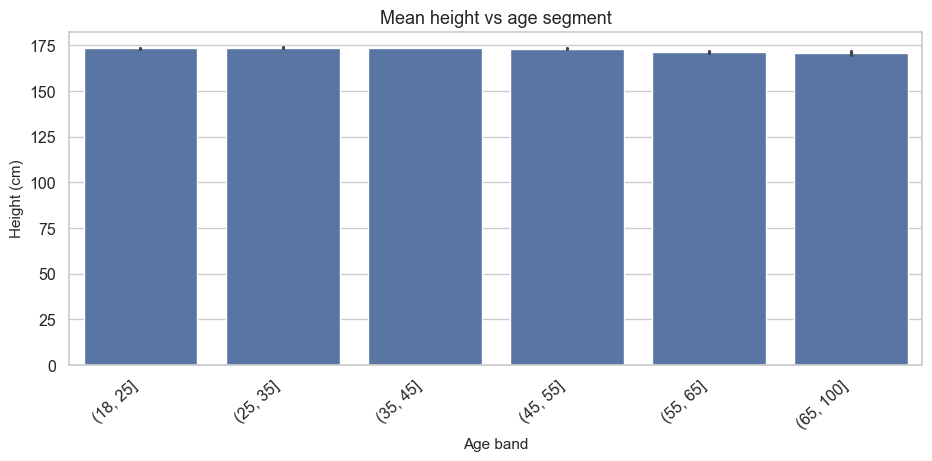

In [37]:
fig, ax = plt.subplots(figsize=FIG_MD)
sns.barplot(ax=ax, data=df, x="age_band", y="height_cm")
ax.set_title("Mean height vs age segment")
ax.set_xlabel("Age band")
ax.set_ylabel("Height (cm)")
plt.xticks(rotation=42, ha="right")
plt.tight_layout()
plt.show()


### Insight

Marginal downward slope at older cohorts aligns with demographics; watch for truncation driven by thinner older samples.


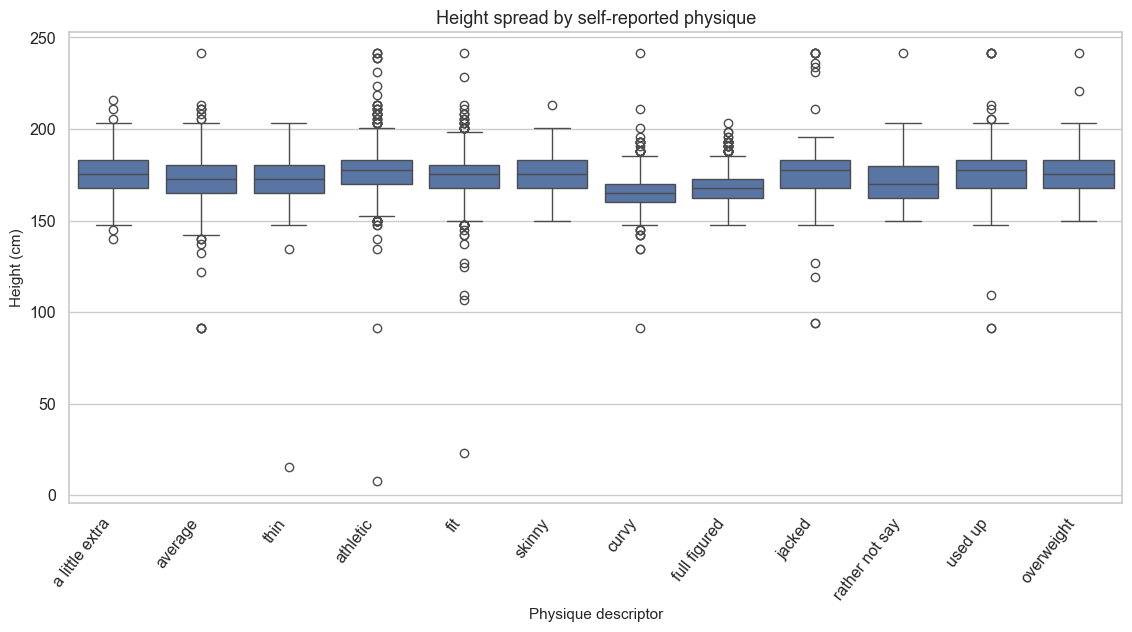

In [38]:
fig, ax = plt.subplots(figsize=FIG_XL)
sns.boxplot(ax=ax, data=df, x="body_type", y="height_cm")
ax.set_title("Height spread by self-reported physique")
ax.set_xlabel("Physique descriptor")
ax.set_ylabel("Height (cm)")
plt.xticks(rotation=52, ha="right")
plt.tight_layout()
plt.show()


### Insight

Medians sit in a moderately tight corridor; outliers may reflect joking entries or mismatched physique tags—worth periodic QA.


### Economics — income


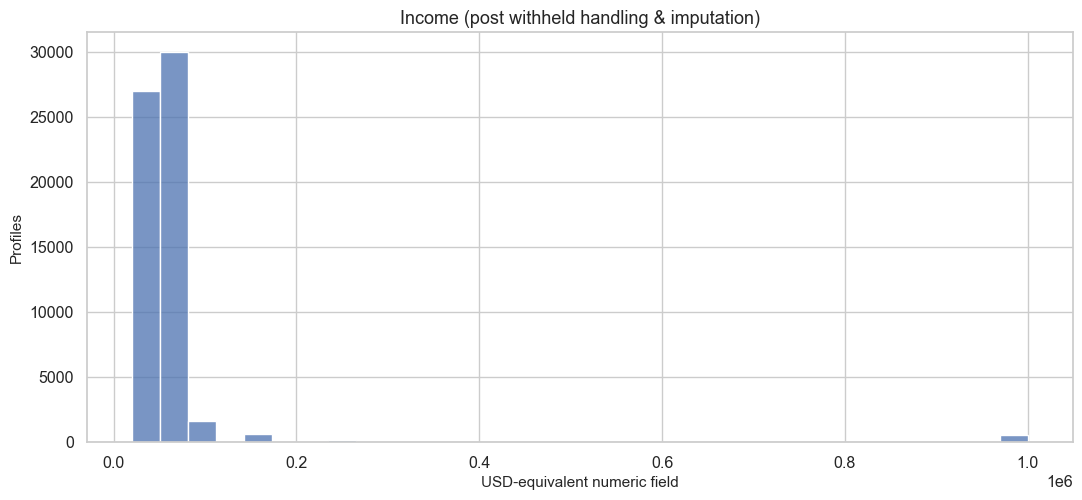

In [39]:
fig, ax = plt.subplots(figsize=FIG_LG)
sns.histplot(ax=ax, data=df, x="income", bins=32, kde=False)
ax.set_title("Income (post withheld handling & imputation)")
ax.set_xlabel("USD-equivalent numeric field")
ax.set_ylabel("Profiles")
plt.tight_layout()
plt.show()


### Insight

Long right tail persists even after strata fills—monetization or upsell hypotheses should cite verified subsets, not imputed extremes.


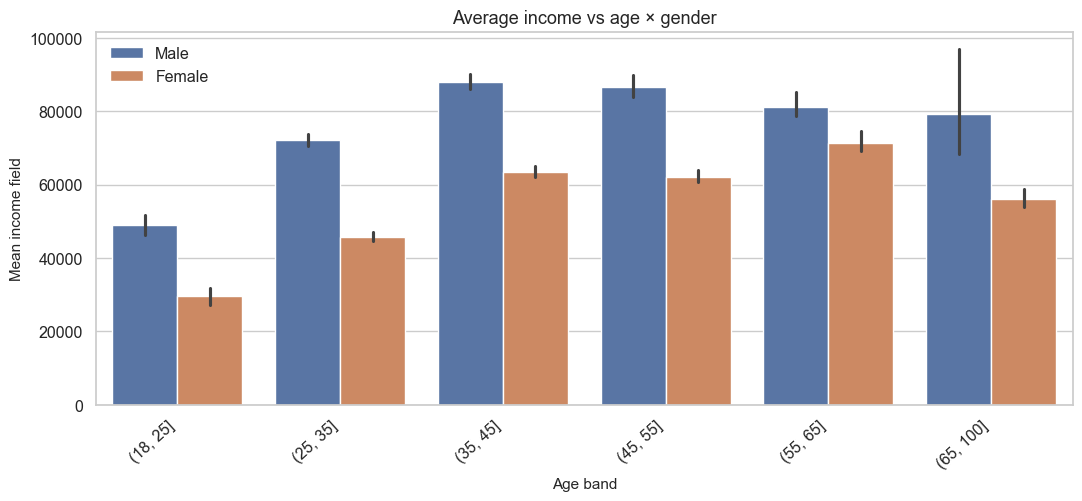

In [40]:
fig, ax = plt.subplots(figsize=FIG_LG)
sns.barplot(ax=ax, data=df, x="age_band", y="income", hue="gender", hue_order=["m", "f"])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ["Male", "Female"], title="", frameon=False, loc="upper left")
ax.set_title("Average income vs age × gender")
ax.set_xlabel("Age band")
ax.set_ylabel("Mean income field")
plt.xticks(rotation=42, ha="right")
plt.tight_layout()
plt.show()


### Insight

Older bands average higher—not causal proof of cohort wealth, but a hypothesis for tailoring premium positioning tests.


### Lifecycle — ages


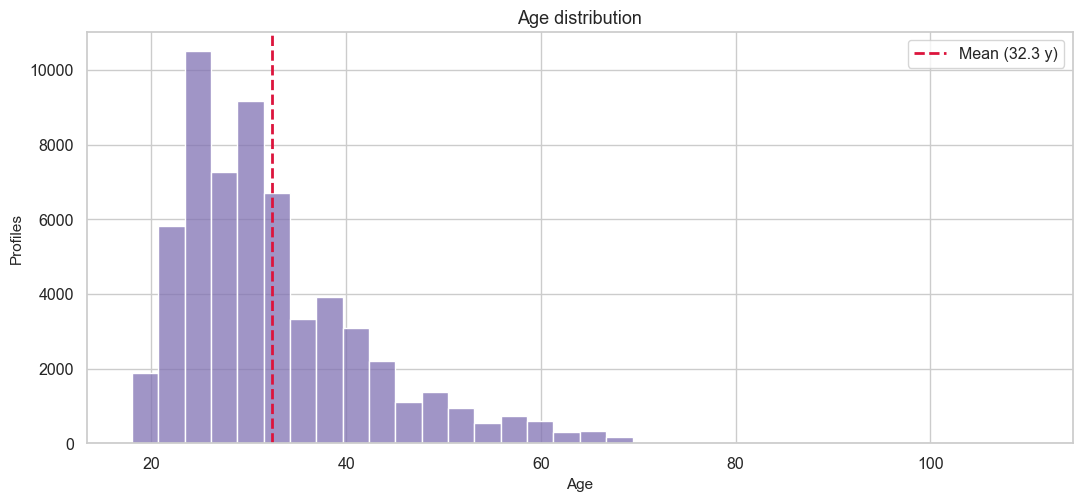

In [41]:
fig, ax = plt.subplots(figsize=FIG_LG)
sns.histplot(ax=ax, data=df, x="age", bins=34, color="#8172B3")
mean_age_years = df["age"].mean()
ax.axvline(mean_age_years, color="crimson", linestyle="--", linewidth=2, label=f"Mean ({mean_age_years:.1f} y)")
ax.set_title("Age distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Profiles")
ax.legend()
plt.tight_layout()
plt.show()


### Insight

Mass sits in roaring-twenties / early-career corridors—pricing, notification tone, and event partnerships should resonate with daytime workers.


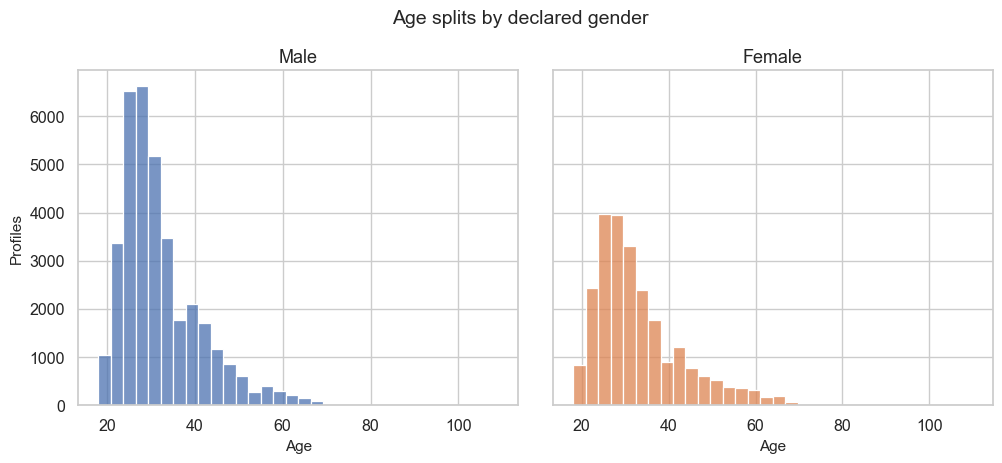

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.35), sharey=True, gridspec_kw={"wspace": 0.08})
palette = {"m": "#4C72B0", "f": "#DD8452"}
for ax_side, gender_code in zip(axes, ["m", "f"]):
    sns.histplot(
        ax=ax_side,
        data=df[df["gender"] == gender_code],
        x="age",
        bins=32,
        color=palette[gender_code],
    )
    ax_side.set_title(GENDER_TICKS[gender_code])
    ax_side.set_xlabel("Age")
axes[0].set_ylabel("Profiles")
plt.suptitle("Age splits by declared gender", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### Insight

Side panels surface subtle skew (which band peaks first) faster than overcrowded overlays.


### Income versus age


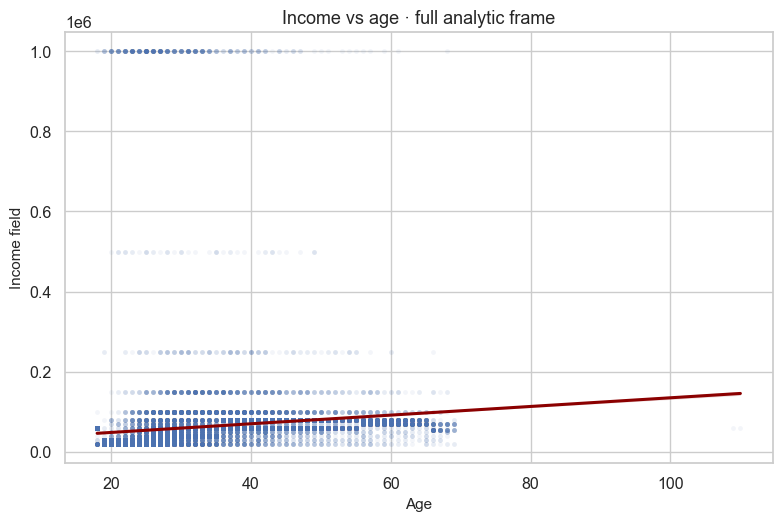

In [43]:
fig, ax = plt.subplots(figsize=(8, 5.4))
sns.scatterplot(ax=ax, data=df, x="age", y="income", alpha=0.065, linewidth=0, s=12)
sns.regplot(ax=ax, data=df, x="age", y="income", scatter=False, color="darkred", line_kws={"linewidth": 2.2})

ax.set_title("Income vs age · full analytic frame")
ax.set_xlabel("Age")
ax.set_ylabel("Income field")
plt.tight_layout()
plt.show()


### Insight

Cloud density tilts upward with age but variance dominates—lifetime value models need multi-feature embeddings, not this line alone.


### Income dispersion by strata


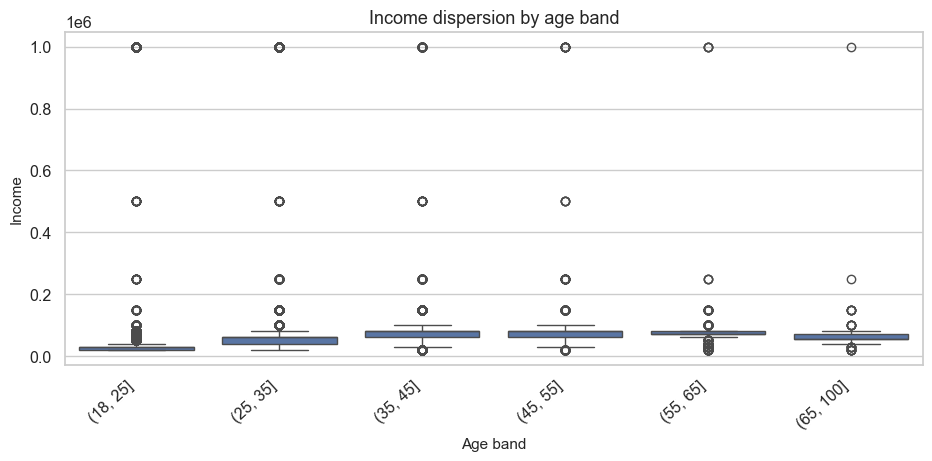

In [44]:
fig, ax = plt.subplots(figsize=FIG_MD)
sns.boxplot(ax=ax, data=df, x="age_band", y="income")
ax.set_title("Income dispersion by age band")
ax.set_xlabel("Age band")
ax.set_ylabel("Income")
plt.xticks(rotation=42, ha="right")
plt.tight_layout()
plt.show()


### Insight

Age slices ladder upward visually; residuals still dominate—premium pricing tests should stratify QA by band to avoid regressing on hidden skew.


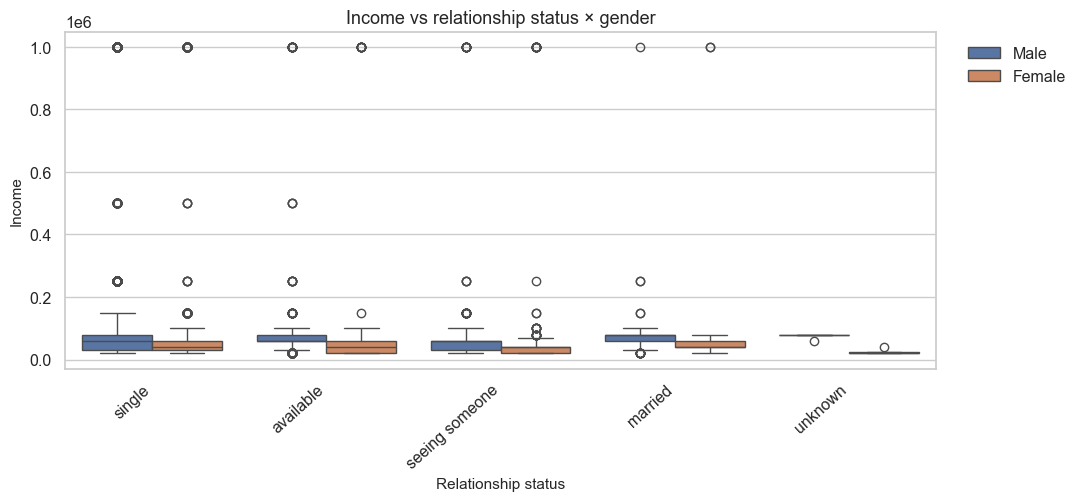

In [45]:
fig, ax = plt.subplots(figsize=FIG_LG)
sns.boxplot(ax=ax, data=df, x="status", y="income", hue="gender", hue_order=["m", "f"])
_handles, _ = ax.get_legend_handles_labels()
ax.legend(_handles[:2], ["Male", "Female"], title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_title("Income vs relationship status × gender")
ax.set_xlabel("Relationship status")
ax.set_ylabel("Income")
plt.xticks(rotation=42, ha="right")
plt.tight_layout()
plt.show()


### Insight

Boxes compress the story versus scatter noise—premium targeting should cite medians/IQR splits, while marketing stories avoid max-value anecdotes.


### Leisure signals


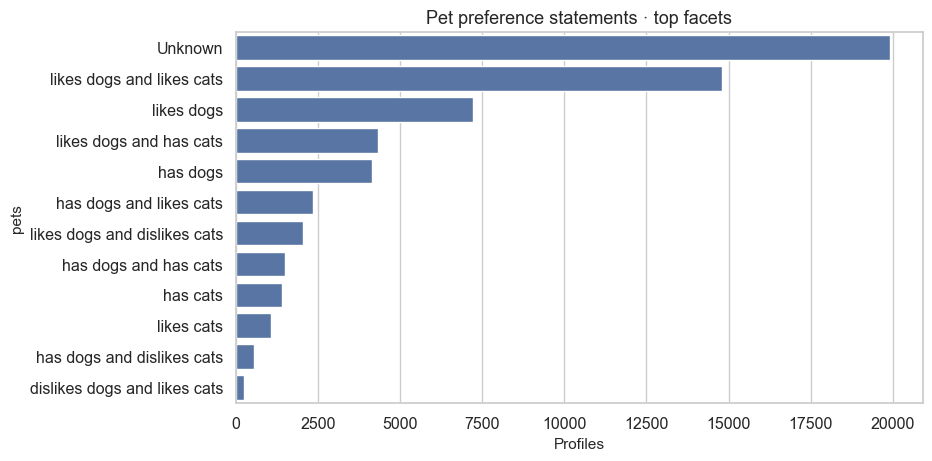

In [46]:
fig, ax = plt.subplots(figsize=FIG_MD)
sns.countplot(ax=ax, data=df, y="pets", order=df["pets"].value_counts().index[:12])
ax.set_title("Pet preference statements · top facets")
ax.set_xlabel("Profiles")
plt.tight_layout()
plt.show()


### Insight

Dog-forward language dominates microcopy prompts and date ideas—for example “dog-friendly patios” outperform generic icebreakers.


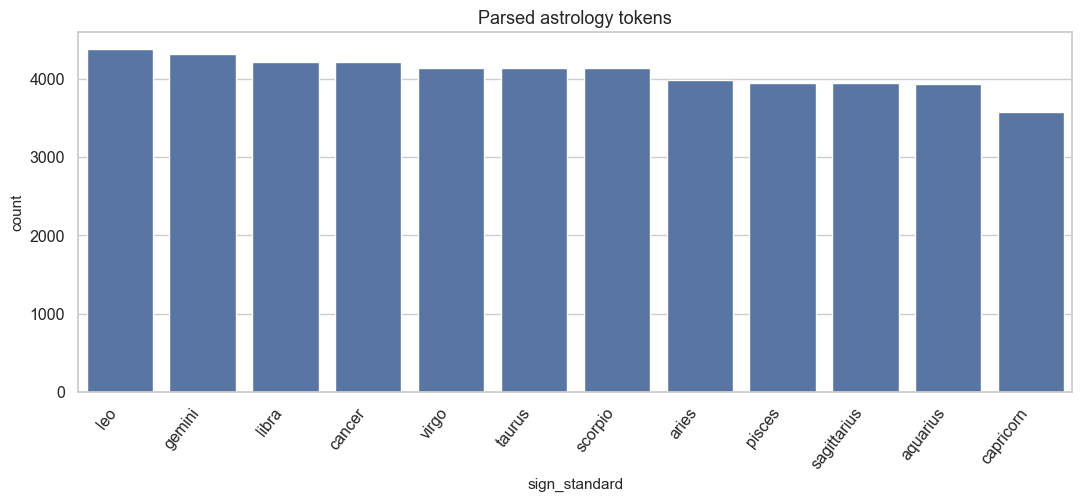

In [47]:
sign_order = df["sign_standard"].value_counts(dropna=True).index

fig, ax = plt.subplots(figsize=FIG_LG)
sns.countplot(ax=ax, data=df.dropna(subset=["sign_standard"]), x="sign_standard", order=sign_order)
ax.set_title("Parsed astrology tokens")
plt.xticks(rotation=52, ha="right")
plt.tight_layout()
plt.show()


### Insight

Fairly balanced tokens—thin incremental lift vs gender for recommendations, mainly a personalization garnish.


### Final dataset postcard


In [48]:
profile_summary_row = pd.DataFrame(
    [{"profiles": len(df), "median_age": df["age"].median(), "median_height_cm": df["height_cm"].median(), "median_income_field": df["income"].median()}])

display(profile_summary_row)

df[["age", "height_cm", "income"]].describe().round(1).T


,profiles,median_age,median_height_cm,median_income_field
0,59943,30.0,172.72,60000.0


,count,mean,std,min,25%,50%,75%,max
age,59943.0,32.3,9.5,18.0,26.0,30.0,37.0,110.0
height_cm,59943.0,173.5,10.1,2.5,167.6,172.7,180.3,241.3
income,59943.0,61339.0,92214.9,20000.0,30000.0,60000.0,60000.0,1000000.0


### Closing snapshot Numeric envelopes post-clean remain stable (`df` ready for dashboards or modeled features).


---
## Key Findings

| Signal | Observation |
|---|---|
| Audience | ~60% male vs ~40% female → asymmetric competition on marketplace |
| Intent | Relationship status concentrates on **single**—product-market fit cue |
| Data quality | **Majority** withheld income historically; sentinel handling required |
| Age | Bulk of mass in **young adult–early career** years |
| Location | Density in a handful of **metro clusters** simplifies geo experiments |
| Lifestyle | Flexible diet + pet-centric preferences shape messaging hooks |

_Exploratory, non-causal — validate via experiments._


---
## Business Recommendations

1. **Supply-side balance.** Run ethically sourced acquisition & referral plays that widen under-represented segments; monitor reply-rate delta as the north star.  
2. **Transparency without friction.** Pilot soft trust proofs (education / employer stubs) ahead of intrusive income prompts; treat raw income as unreliable for ranking.  
3. **Hyper-local playbook.** Concentrate influencer + event spend where profile density concentrates; localize creative instead of statewide generic ads.  
4. **Icebreakers that convert.** Embed pet-aware and diet-safe suggested openers surfaced from dominant lifestyle clusters.  
5. **Operational QA.** Periodic rules on impossible age / height combos catch low-effort spoofing before moderation queues spike.


---
## Conclusion

Ran a recruiter-style exploratory pass: sentinel cleanup, categorical harmonization, charts sized for skim, capped with experiments—not proof of causality.


## Skills Demonstrated

- Python  
- Pandas  
- NumPy  
- Seaborn  
- Matplotlib  
- Data Cleaning  
- EDA  
- Feature Engineering  
- Business Insights  
- Data Visualization  

These competencies reflect day-to-day **Data Analyst / exploratory analytics** deliverables showcased end-to-end in this workbook.


***

*Project developed for portfolio demonstration and educational analysis purposes.*
